<div align="center">


# CSE-422 PROJECT REPORT

## PREDICTIVE MODELING AND ANALYSIS FOR DEPRESSION RISK USING MACHINE LEARNING TECHNIQUES

</div>

---

**Semester:** Summer 2026

**Submitted By:**
* **Name:** Utsho Heaven Chowdhury | **Student ID:** 21201574
* **Name:** Utsho Heaven Chowdhury | **Student ID:** 21201574


**Section:** 09 | **Group:** [Group No.]


**Submission Date:** [Date]

---

## Table of Contents

* **1. Introduction** ............................................................................................ Page 1
  * 1.1 Project Aim
  * 1.2 Problem Statement
  * 1.3 Motivation
* **2. Dataset Description & Exploratory Data Analysis (EDA)** ..................... Page 2
* **3. Dataset Pre-processing** ........................................................................ Page 4
* **4. Dataset Splitting** .................................................................................... Page 5
* **5. Model Training & Testing (Supervised)** .............................................. Page 6
* **6. Unsupervised Learning** ......................................................................... Page 8
* **7. Model Selection & Comparison Analysis** ............................................. Page 9
* **8. Conclusion** .............................................................................................. Page 11





---




## 1. Introduction

### 1.1 Project Aim
This project aims to develop and evaluate predictive machine learning models capable of classifying the risk and severity of depression in individuals. By analyzing demographic details, academic metrics, and responses to psychometric questionnaires, the project seeks to build an automated diagnostic tool using both supervised algorithms and unsupervised clustering techniques.

### 1.2 Problem Statement
Depression is frequently underdiagnosed or detected late due to social stigma, limited access to mental health professionals, and a heavy reliance on manual, subjective screening processes. Traditional diagnostic workflows are resource-intensive and lack the scalability required for broad, early-warning detection. The technical challenge is to identify distinct risk patterns and accurately classify individuals while minimizing false negatives in the dataset.

### 1.3 Motivation
Mental health disorders are a leading cause of global health burdens, severely impacting personal well-being, academic performance, and overall quality of life. The motivation behind this project is to leverage machine learning to discover complex relationships between academic pressure, behavioral habits, and mental state. An automated predictive model can serve as an early-intervention aid for counselors and healthcare providers, helping to identify high-risk individuals before severe clinical escalation occurs.

In [20]:

%pip install pandas numpy matplotlib seaborn scikit-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset 
df = pd.read_csv("Depression Data.csv")

# Display dataset info
df.info()

Note: you may need to restart the kernel to use updated packages.
<class 'pandas.DataFrame'>
RangeIndex: 1977 entries, 0 to 1976
Data columns (total 37 columns):
 #   Column                                                                                                                                                                 Non-Null Count  Dtype
---  ------                                                                                                                                                                 --------------  -----
 0   1. Age                                                                                                                                                                 1977 non-null   str  
 1   2. Gender                                                                                                                                                              1971 non-null   str  
 2   5. Academic Year                                         


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Dataset Description & Exploratory Data Analysis (EDA)

### Dataset Description

* 
  There are a total of 37 features (columns) in the dataset, which include the input attributes and the target variable.

* This is a **classification** problem. The target variable we aim to predict is `Depression Label`. Because this target consists of distinct, discrete categories (e.g., different severity levels of depression) rather than a continuous numerical value, supervised classification algorithms are the appropriate approach.

* The dataset contains **1,977** data points (rows).

* The dataset contains a mix of both types:
  * **Quantitative:** 29 features are numerical, representing ordinal responses to psychological questionnaires and aggregated assessment scores.
  * **Categorical:** 8 features are categorical, representing demographic and academic information. 

* The categorical variables must be encoded. Machine learning algorithms (such as K-Nearest Neighbors, Logistic Regression, and Neural Networks) rely on mathematical equations and distance calculations to learn patterns. These models cannot process raw text or string data, so categorical features must be transformed into numerical formats using techniques like `Label Encoding` or `One-Hot Encoding`.

* **Correlation of all the features (apply heatmap using the seaborn library)**
  *(See the generated correlation heatmap below)*

*  
  Based on the correlation heatmap, several key insights emerge regarding the relationships between the features:
  * **Grouped questions are strongly linked:** Dark red blocks show that questions on the same topic (like anxiety) are highly correlated. High scores on one usually mean high scores on the rest.
  * **Stress, Anxiety, and Depression are connected:** Red areas linking the total scores show that students with high academic stress or anxiety also tend to have higher depression scores.
  * **Confidence lowers depression (Negative Correlation):** Blue areas highlight an opposite relationship. As a student's confidence and sense of control increase, their stress and depression scores decrease.

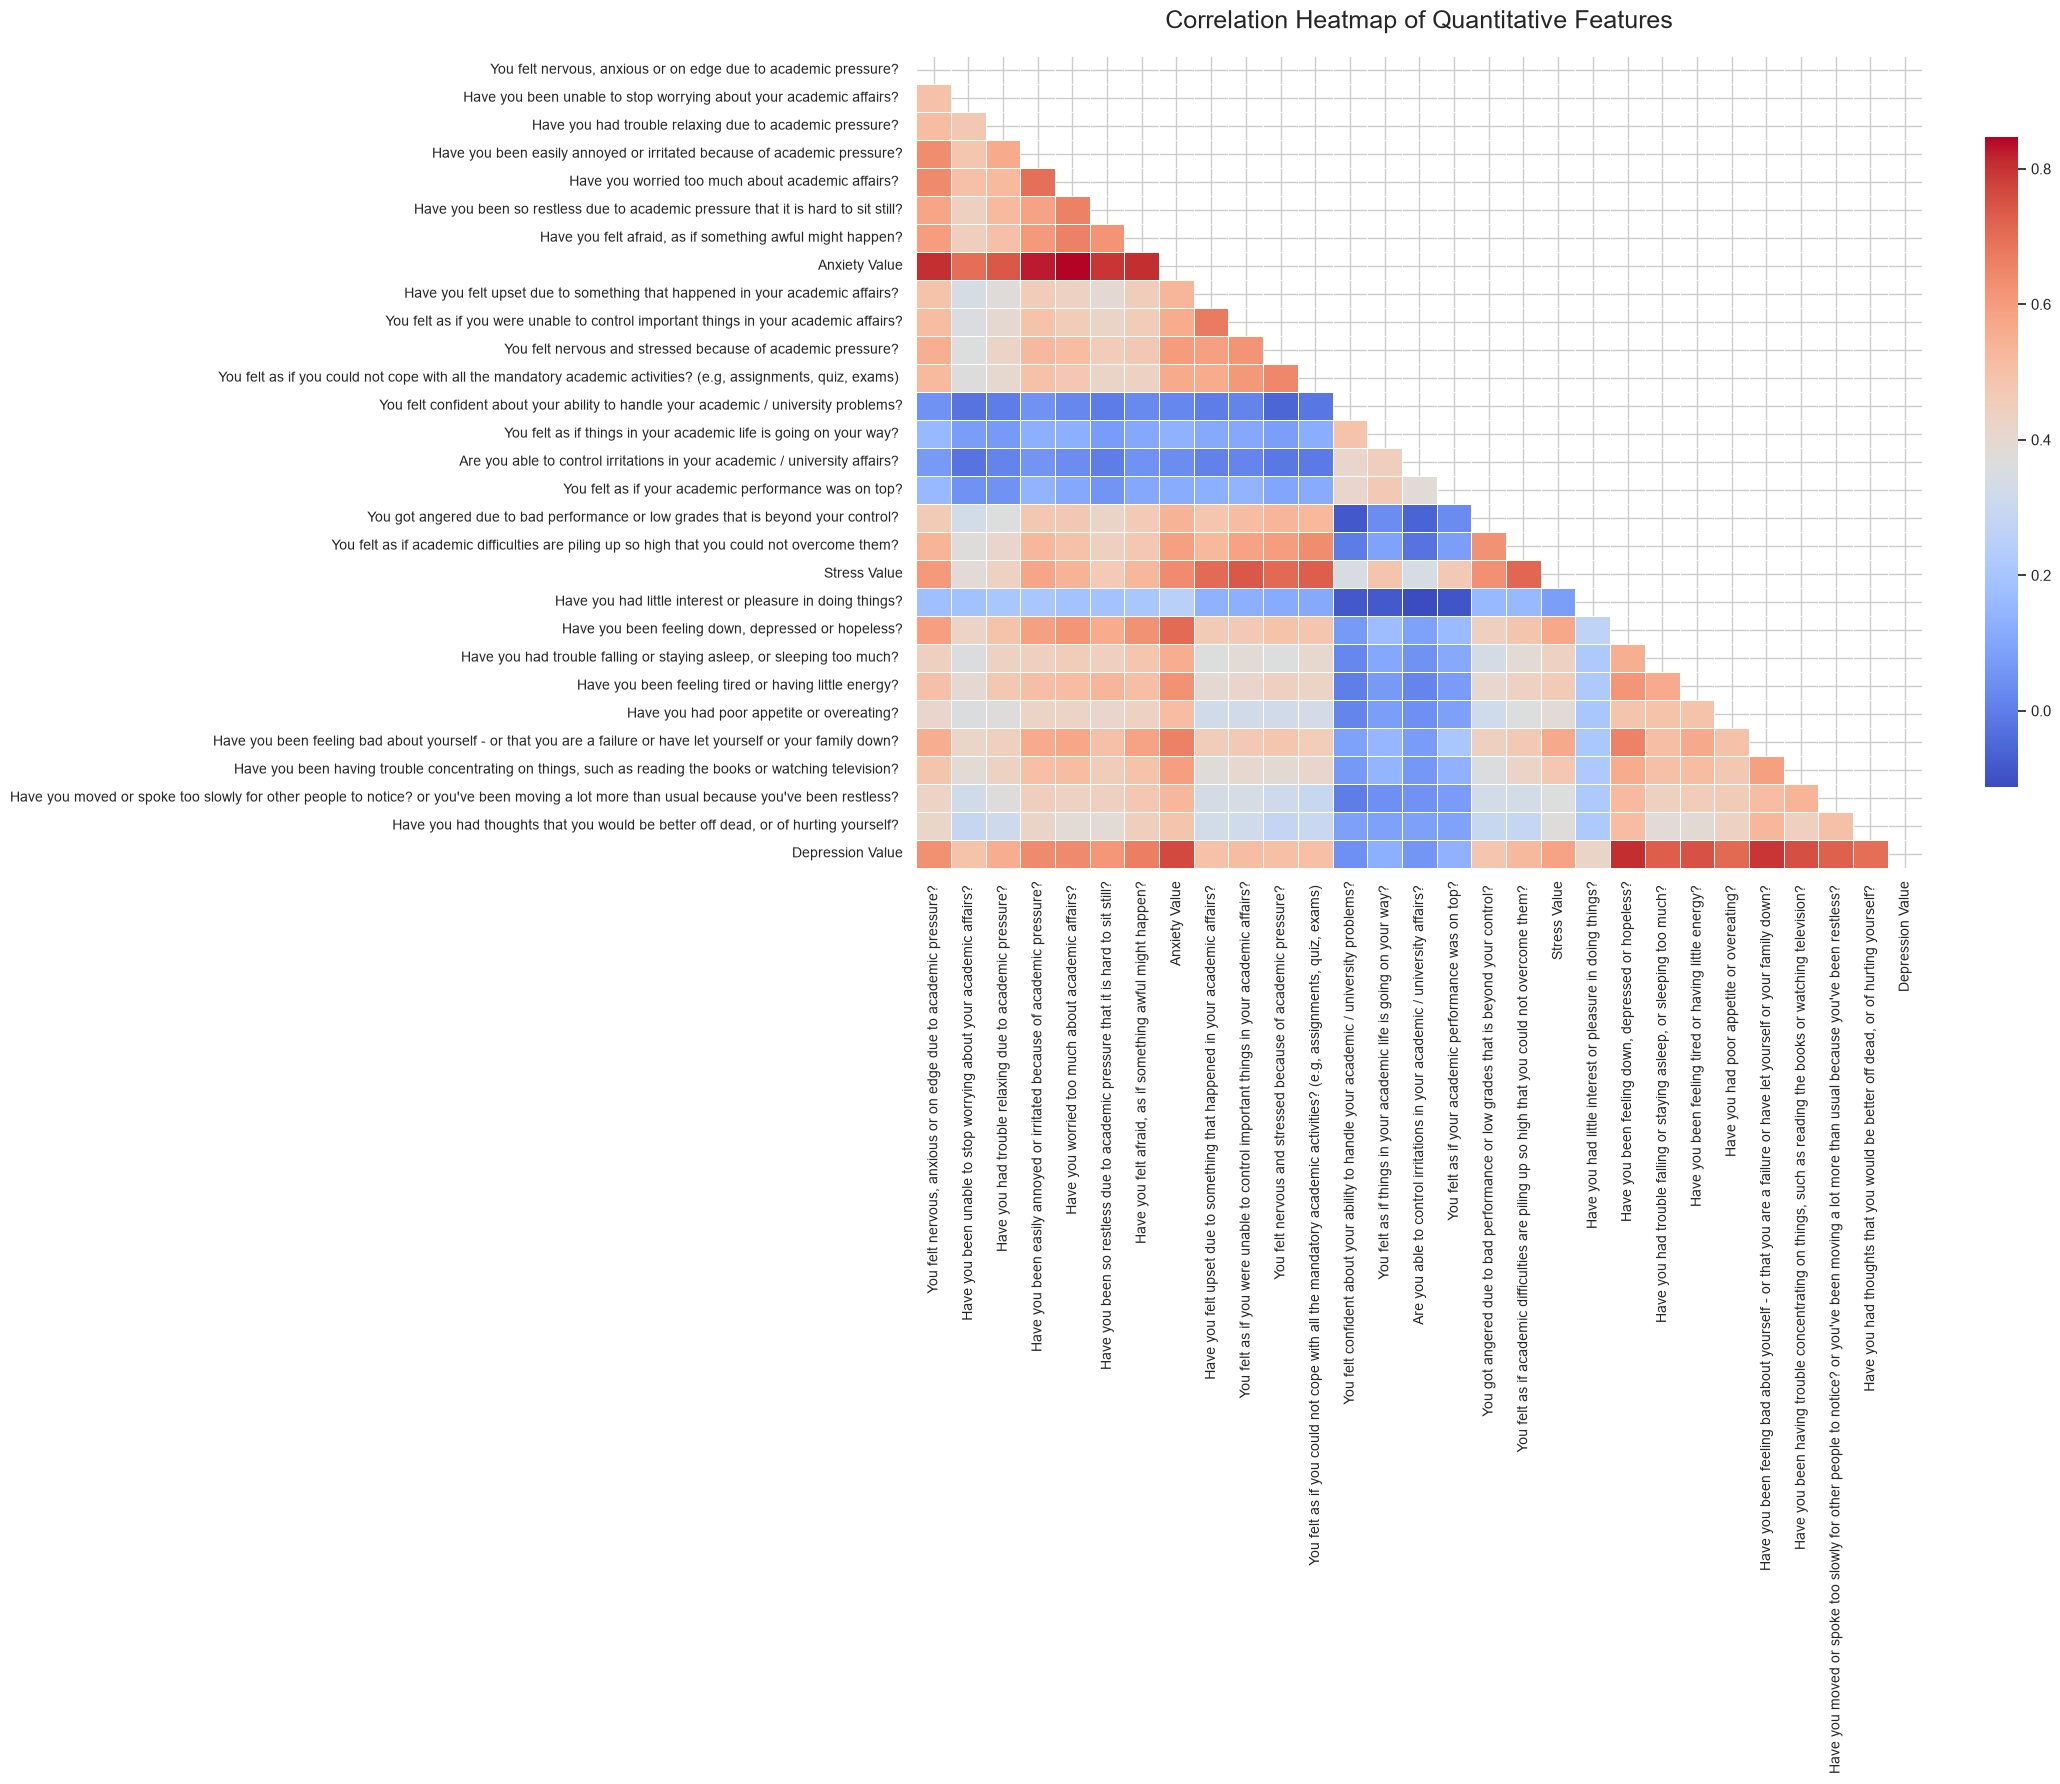

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Filter only quantitative (numerical) columns
numeric_df = df.select_dtypes(include=['int64'])

# 2. Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# 3. Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 4. Clean the labels by removing the repetitive prefix
clean_labels = []
for col in numeric_df.columns:
    if "how often " in col:
        # Keep everything after "how often "
        clean_name = col.split("how often ")[-1]
        # Capitalize the first letter to make it look clean
        clean_name = clean_name.capitalize()
        clean_labels.append(clean_name)
    else:
        clean_labels.append(col)

# 5. Set up the figure size (slightly wider to fit the text)
plt.figure(figsize=(22, 18))

# 6. Plot the cleaned heatmap
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', 
            xticklabels=clean_labels, yticklabels=clean_labels, 
            linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap of Quantitative Features', fontsize=18, pad=20)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13564\668035546.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Depression Label', palette='viridis',


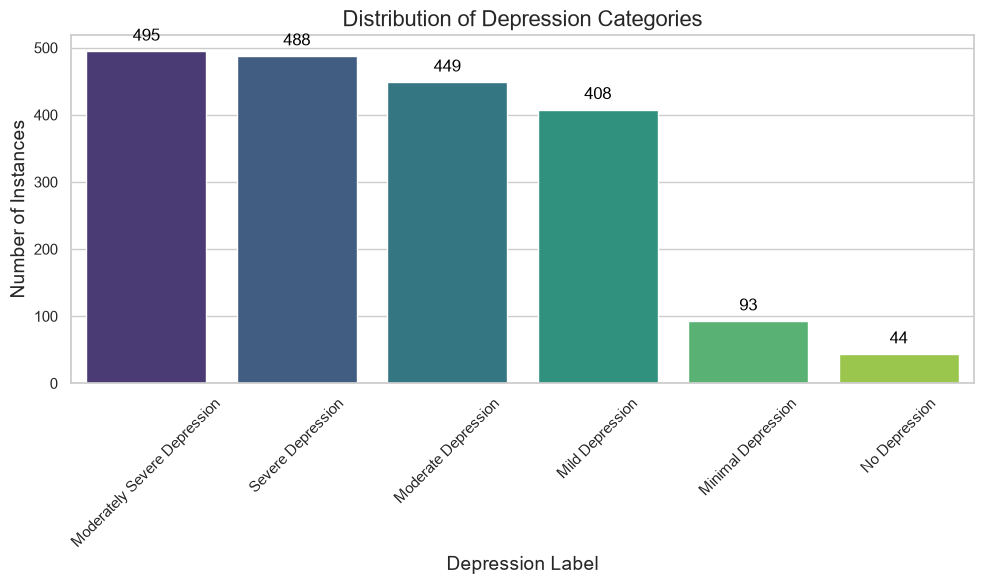

In [22]:
# Create the Bar Chart for the Target Variable
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Depression Label', palette='viridis', 
                   order=df['Depression Label'].value_counts().index)

# Add counts on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Distribution of Depression Categories', fontsize=16)
plt.xlabel('Depression Label', fontsize=14)
plt.ylabel('Number of Instances', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Imbalanced Dataset

* The dataset is imbalanced. The target variable (`Depression Label`) does not have an equal distribution across its six classes. The majority of the instances are concentrated in the higher severity categories, with **Moderately Severe Depression** having the highest count (495 instances), followed closely by **Severe Depression** (488 instances). In contrast, the minority classes are drastically underrepresented, with **Minimal Depression** containing only 93 instances and **No Depression** containing just 44 instances. This imbalance means the model will train on far fewer examples of healthy individuals, which could bias predictions toward higher severity levels if not addressed during preprocessing.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13564\3343691698.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Depression Label', palette='viridis',


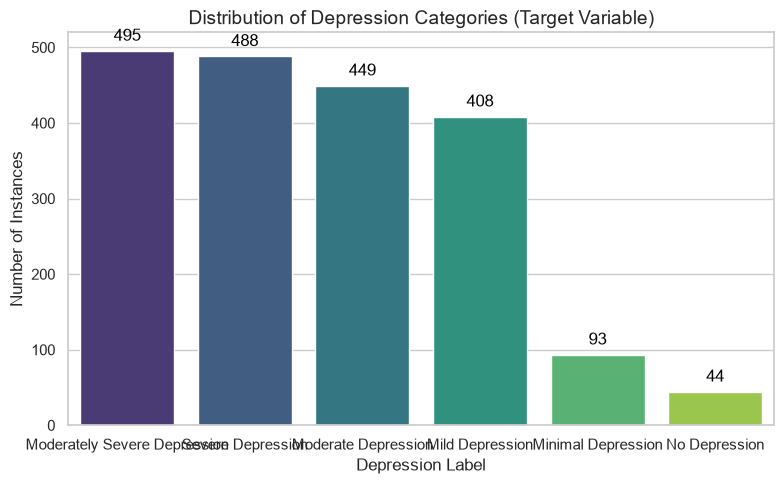


Exact counts for Imbalanced Dataset section:
Depression Label
Moderately Severe Depression    495
Severe Depression               488
Moderate Depression             449
Mild Depression                 408
Minimal Depression               93
No Depression                    44
Name: count, dtype: int64


In [23]:
# ---------------------------------------------------------
# 1. Target Variable Distribution (To check for Imbalance)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Depression Label', palette='viridis', 
                   order=df['Depression Label'].value_counts().index)

# Print the exact numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Distribution of Depression Categories (Target Variable)', fontsize=14)
plt.xlabel('Depression Label', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)
plt.tight_layout()
plt.show()

# Print the exact counts to fill in your report text
print("\nExact counts for Imbalanced Dataset section:")
print(df['Depression Label'].value_counts())

### Exploratory Data Analysis (EDA) - Important Relationships

To extract important relationships from the data, several exploratory visualizations were generated:

1. **Depression Severity vs. Stress Levels:** A boxplot analyzing the relationship between the `Aggregate Stress Value` and `Depression Label` shows a distinct upward trend. Individuals categorized with "Severe" or "Moderately Severe" depression consistently exhibit much higher median stress values (clustering between 20 and 30) compared to those with "Minimal" or "No Depression" (clustering below 20). This confirms that aggregate stress is a strong positive indicator of depression severity.
  *(Insert the "Relationship between Total Stress Value and Depression Severity" boxplot here)*

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13564\780731683.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Depression Label', y='Stress Value', palette='magma',


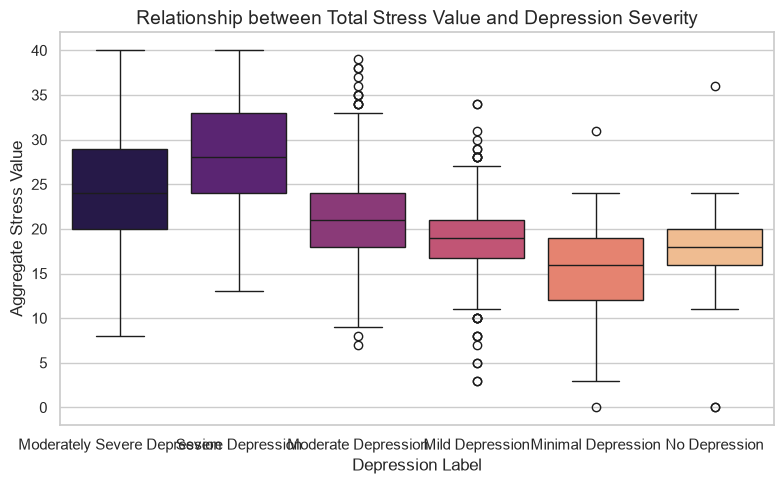

In [24]:
# ---------------------------------------------------------
# 2. EDA Relationship 1: Stress Value vs. Depression Label
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Depression Label', y='Stress Value', palette='magma', 
            order=df['Depression Label'].value_counts().index)
plt.title('Relationship between Total Stress Value and Depression Severity', fontsize=14)
plt.xlabel('Depression Label', fontsize=12)
plt.ylabel('Aggregate Stress Value', fontsize=12)
plt.tight_layout()
plt.show()


2. **Depression Distribution by Gender:** A grouped bar chart reveals a significant gender disparity within the dataset. Across almost all depression categories—particularly Moderate, Moderately Severe, and Severe—the number of male instances is significantly higher than female instances. This indicates that gender is a highly influential demographic feature and highlights a specific demographic skew in the sampled population.

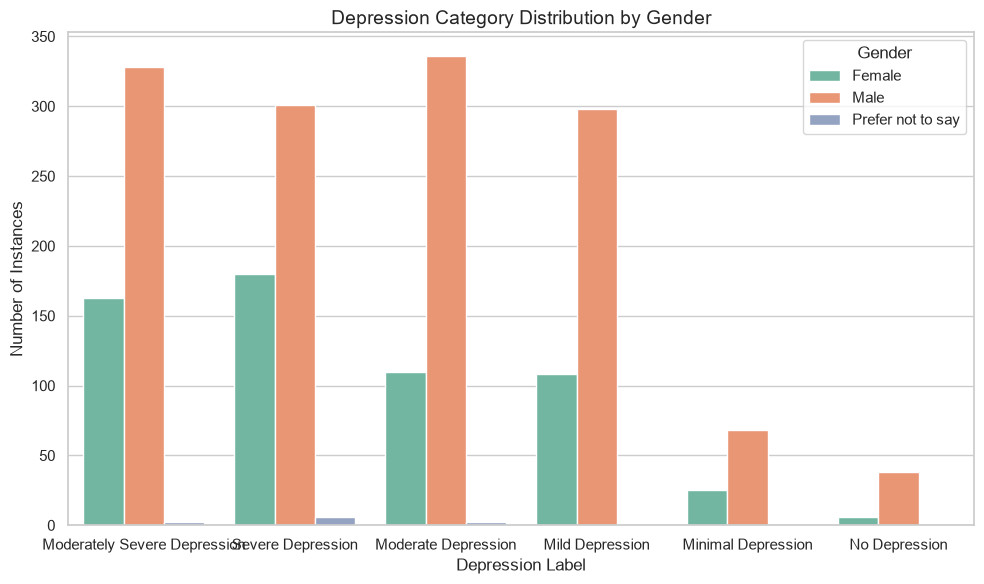

In [25]:
# ---------------------------------------------------------
# 3. EDA Relationship 2: Depression Label grouped by Gender
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Depression Label', hue='2. Gender', palette='Set2', 
              order=df['Depression Label'].value_counts().index)
plt.title('Depression Category Distribution by Gender', fontsize=14)
plt.xlabel('Depression Label', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()